# BASIC PROJECT TO GET E

In [ ]:
import importlib
import base_project as bp


## 1.1

### 1.1.1 *Download a pre-trained modern ConvNet such as: ResNet18, ResNet34,...*

In [ ]:
import torchvision.models as models

# download pretrained resnet34
# **THIS ONLY DOWNLOADS THE FIRST TIME IT RUNS, THEN GETS CACHED
model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

# validate model
print(model)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### 1.1.2 *Download the dataset*

Heads up the file is pretty big so I wasn't able to add it to the git repo, but theres directions in the assignment for where to get the data, and I documented how this code expects your local directory to look in the readme.

In [ ]:
# extract data
import tarfile

for fname in ['images.tar.gz', 'annotations.tar.gz']:
    with tarfile.open(f'./dataset/oxford-iiit-pet/{fname}') as tar:
        tar.extractall('./dataset/oxford-iiit-pet/')


/var/folders/jp/90g4mw8n1xl74z8kt8jj8s700000gn/T/ipykernel_11002/2871605484.py:6: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall('./dataset/oxford-iiit-pet/')


### 1.1.3 *sanity check*

#### load in data

In [ ]:
import base_project as bp

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # normalization values for ImageNet (ResNet)
    transforms.Normalize(
        mean = [0.485, 0.456, 0.406],
        std  = [0.229, 0.224, 0.225]
    )
])

train_data = datasets.OxfordIIITPet(root='./dataset', split='trainval',
                                     download=False, transform=transform)
test_data  = datasets.OxfordIIITPet(root='./dataset', split='test',
                                     download=False, transform=transform)

# convert labels to binary (dog=0, cat=1)
train_dataset = bp.BinaryPetDataset(train_data)
test_dataset = bp.BinaryPetDataset(test_data)

# set dataloader wrappers
train_loader = DataLoader(train_dataset,
                          batch_size=32, 
                          shuffle=True,
                          num_workers=2)
test_loader = DataLoader(test_dataset,
                          batch_size=32, 
                          shuffle=False, 
                          num_workers=2)


In [ ]:
import torch
import torch.nn as nn

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# freeze all layers (for sanity check)
for param in model.parameters():
    param.requires_grad = False

# unfreeze layer 4 and fc 
for param in model.layer4.parameters():
    param.requires_grad = True
for param in model.fc.parameters():
    param.requires_grad = True

# modify network for binary classification
model.fc = nn.Linear(512, 1)
model = model.to(device)

# init optimizer and loss function
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
criterion = nn.BCEWithLogitsLoss()


#### actually run sanity check

In [ ]:
num_epochs = 5

for epoch in range(num_epochs):
    train_loss, train_accuracy = bp.train_epoch_binary(model, train_loader, optimizer, criterion, device)
    test_loss, test_accuracy = bp.train_epoch_binary(model, test_loader, optimizer, criterion, device)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train loss: {train_loss:.4f}, accuracy: {train_accuracy:.4f} | "
          f"Test loss: {test_loss:.4f}, accuracy: {test_accuracy:.4f}")


Epoch 1/5 | Train loss: 0.0624, accuracy: 0.9802 | Test loss: 0.6892, accuracy: 0.6743
Epoch 2/5 | Train loss: 0.0525, accuracy: 0.9935 | Test loss: 0.3453, accuracy: 0.8915
Epoch 3/5 | Train loss: 0.0374, accuracy: 0.9976 | Test loss: 0.1660, accuracy: 0.9586
Epoch 4/5 | Train loss: 0.0230, accuracy: 0.9978 | Test loss: 0.0743, accuracy: 0.9932
Epoch 5/5 | Train loss: 0.0093, accuracy: 0.9997 | Test loss: 0.0367, accuracy: 0.9995


### 1.1.4 *multi-class linear probing*

In [ ]:
train_loader = DataLoader(train_data,
                          batch_size=32, 
                          shuffle=True,
                          num_workers=2)
test_loader = DataLoader(test_data,
                          batch_size=32, 
                          shuffle=False, 
                          num_workers=2)


model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

# freeze model
for param in model.parameters():
    param.requires_grad = False

# only train on new head (linear probing)
model.fc = nn.Linear(512, 37)
model = model.to(device)

optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
# change loss function to standard cross entropy loss for multi-class
criterion = nn.CrossEntropyLoss()


In [ ]:
num_epochs = 5

for epoch in range(num_epochs):
    train_loss, train_acc = bp.train_epoch(model, train_loader, optimizer, criterion, device)
    test_loss,  test_acc  = bp.evaluate_epoch(model, test_loader, criterion, device)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
          f"Test loss: {test_loss:.4f}, acc: {test_acc:.4f}")


Epoch 1/5 | Train loss: 1.8210, acc: 0.6041 | Test loss: 0.8256, acc: 0.8179
Epoch 2/5 | Train loss: 0.6134, acc: 0.8734 | Test loss: 0.5291, acc: 0.8659
Epoch 3/5 | Train loss: 0.4246, acc: 0.9016 | Test loss: 0.4502, acc: 0.8708
Epoch 4/5 | Train loss: 0.3380, acc: 0.9242 | Test loss: 0.4102, acc: 0.8823
Epoch 5/5 | Train loss: 0.2721, acc: 0.9391 | Test loss: 0.3903, acc: 0.8793


## 1.2 Fine-tuning the network

### 1.2.1 Strategy 1: Fine-tune last l layers simultaneously

In [ ]:
NUM_EPOCHS = 20
strategy1_results = {}

for l in range(1, 5):
    # bp.set_seed(42)
    model = bp.get_model_finetune(num_classes=37)
    bp.unfreeze_layers(model, l)
    model = model.to(device)
    optimizer = bp.get_optimizer(model, l, base_lr=1e-5)
    criterion = nn.CrossEntropyLoss()

    print(f"\n------ l={l} | unfreezing: fc + {bp.RESNET34_LAYER_GROUPS[:l]} ------")
    epoch_accs = []

    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc = bp.train_epoch(model, train_loader, optimizer, criterion, device)
        test_loss, test_acc   = bp.evaluate_epoch(model, test_loader, criterion, device)
        epoch_accs.append(test_acc)

        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
              f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
              f"Test loss: {test_loss:.4f}, acc: {test_acc:.4f}")

    strategy1_results[l] = max(epoch_accs)
    print(f"Best test acc for l={l}: {strategy1_results[l]:.4f}")

print("\n------ Strategy 1 Summary ------")
for l, acc in strategy1_results.items():
    print(f"l={l}: best test acc = {acc:.4f}")



------ l=1 | unfreezing: fc + ['layer4'] ------
Epoch 1/20 | Train loss: 3.1368, acc: 0.1997 | Test loss: 2.3950, acc: 0.5345
Epoch 2/20 | Train loss: 1.9608, acc: 0.7027 | Test loss: 1.5214, acc: 0.8013
Epoch 3/20 | Train loss: 1.2954, acc: 0.8649 | Test loss: 1.0720, acc: 0.8670
Epoch 4/20 | Train loss: 0.9262, acc: 0.9087 | Test loss: 0.8162, acc: 0.8863
Epoch 5/20 | Train loss: 0.6906, acc: 0.9296 | Test loss: 0.6777, acc: 0.8934
Epoch 6/20 | Train loss: 0.5547, acc: 0.9364 | Test loss: 0.5782, acc: 0.8983
Epoch 7/20 | Train loss: 0.4511, acc: 0.9492 | Test loss: 0.5207, acc: 0.9000
Epoch 8/20 | Train loss: 0.3699, acc: 0.9571 | Test loss: 0.4788, acc: 0.9016
Epoch 9/20 | Train loss: 0.3125, acc: 0.9666 | Test loss: 0.4432, acc: 0.9030
Epoch 10/20 | Train loss: 0.2654, acc: 0.9704 | Test loss: 0.4194, acc: 0.9027
Epoch 11/20 | Train loss: 0.2212, acc: 0.9769 | Test loss: 0.4094, acc: 0.9060
Epoch 12/20 | Train loss: 0.1902, acc: 0.9834 | Test loss: 0.3912, acc: 0.9038
Epoch 13/20 

### 1.2.2 Strategy 2: Gradual un-freezing

In [ ]:
EPOCHS_PER_STAGE = 5
BASE_LR = 5e-5
strategy2_best = 0.0
total_epoch = 0

# bp.set_seed(42)
model = bp.get_model_finetune(num_classes=37).to(device)
criterion = nn.CrossEntropyLoss()

print("------ Strategy 2: Gradual Unfreezing ------")

for stage in range(4):
    bp.unfreeze_layers(model, stage + 1)
    optimizer = bp.get_optimizer(model, stage + 1, base_lr=BASE_LR)

    print(f"\n-- Stage {stage+1} | unfrozen: fc + {bp.RESNET34_LAYER_GROUPS[:stage+1]} --")

    for epoch in range(EPOCHS_PER_STAGE):
        total_epoch += 1
        train_loss, train_acc = bp.train_epoch(model, train_loader, optimizer, criterion, device)
        test_loss, test_acc   = bp.evaluate_epoch(model, test_loader, criterion, device)
        strategy2_best = max(strategy2_best, test_acc)

        print(f"Epoch {total_epoch}/{4*EPOCHS_PER_STAGE} | "
              f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
              f"Test loss: {test_loss:.4f}, acc: {test_acc:.4f}")

print(f"\nBest test acc (Strategy 2): {strategy2_best:.4f}")


------ Strategy 2: Gradual Unfreezing ------

-- Stage 1 | unfrozen: fc + ['layer4'] --
Epoch 1/20 | Train loss: 1.7497, acc: 0.6492 | Test loss: 0.6986, acc: 0.8705
Epoch 2/20 | Train loss: 0.4779, acc: 0.9272 | Test loss: 0.4459, acc: 0.8921
Epoch 3/20 | Train loss: 0.2305, acc: 0.9701 | Test loss: 0.3804, acc: 0.8983
Epoch 4/20 | Train loss: 0.1200, acc: 0.9905 | Test loss: 0.3649, acc: 0.9005
Epoch 5/20 | Train loss: 0.0675, acc: 0.9981 | Test loss: 0.3477, acc: 0.9054

-- Stage 2 | unfrozen: fc + ['layer4', 'layer3'] --
Epoch 6/20 | Train loss: 0.0508, acc: 0.9943 | Test loss: 0.3484, acc: 0.9027
Epoch 7/20 | Train loss: 0.0284, acc: 0.9976 | Test loss: 0.3612, acc: 0.8997
Epoch 8/20 | Train loss: 0.0160, acc: 0.9986 | Test loss: 0.3417, acc: 0.9041
Epoch 9/20 | Train loss: 0.0104, acc: 0.9989 | Test loss: 0.3442, acc: 0.9038
Epoch 10/20 | Train loss: 0.0077, acc: 0.9997 | Test loss: 0.3592, acc: 0.9024

-- Stage 3 | unfrozen: fc + ['layer4', 'layer3', 'layer2'] --
Epoch 11/20 | T

### Result comparison

In [ ]:
print("\n------ Final Comparison ------")
best_l = max(strategy1_results, key=strategy1_results.get)

print(f"Strategy 1 best (l={best_l}): {strategy1_results[best_l]:.4f}")
print(f"Strategy 2 best:       {strategy2_best:.4f}")



------ Final Comparison ------
Strategy 1 best (l=2): 0.9141
Strategy 2 best:       0.9054


### 1.2.3 Train with best strategy : Fine-tune l (l=2) layers simultaneously

Epoch 1/30 | Train loss: 3.2104, acc: 0.1739 | Test loss: 2.4442, acc: 0.4554
Epoch 2/30 | Train loss: 1.9534, acc: 0.6668 | Test loss: 1.4965, acc: 0.7724
Epoch 3/30 | Train loss: 1.2446, acc: 0.8459 | Test loss: 1.0350, acc: 0.8580
Epoch 4/30 | Train loss: 0.8855, acc: 0.9005 | Test loss: 0.7841, acc: 0.8779
Epoch 5/30 | Train loss: 0.6618, acc: 0.9247 | Test loss: 0.6460, acc: 0.8913
Epoch 6/30 | Train loss: 0.5249, acc: 0.9351 | Test loss: 0.5595, acc: 0.8959
Epoch 7/30 | Train loss: 0.4177, acc: 0.9516 | Test loss: 0.5022, acc: 0.9005
Epoch 8/30 | Train loss: 0.3474, acc: 0.9584 | Test loss: 0.4671, acc: 0.9019
Epoch 9/30 | Train loss: 0.2834, acc: 0.9679 | Test loss: 0.4274, acc: 0.9076
Epoch 10/30 | Train loss: 0.2381, acc: 0.9750 | Test loss: 0.4164, acc: 0.9049
Epoch 11/30 | Train loss: 0.1943, acc: 0.9842 | Test loss: 0.3959, acc: 0.9046
Epoch 12/30 | Train loss: 0.1677, acc: 0.9872 | Test loss: 0.3836, acc: 0.9073
Epoch 13/30 | Train loss: 0.1397, acc: 0.9927 | Test loss: 0.

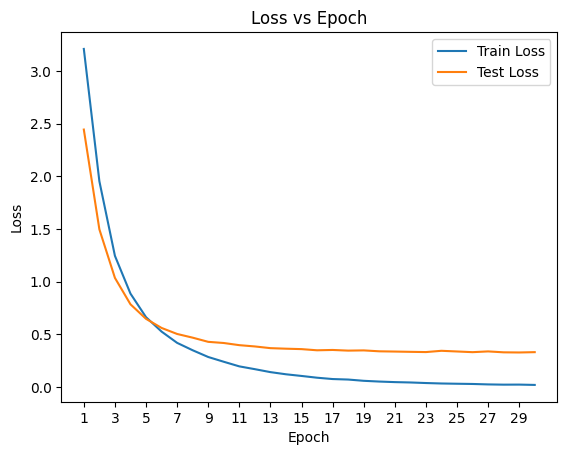

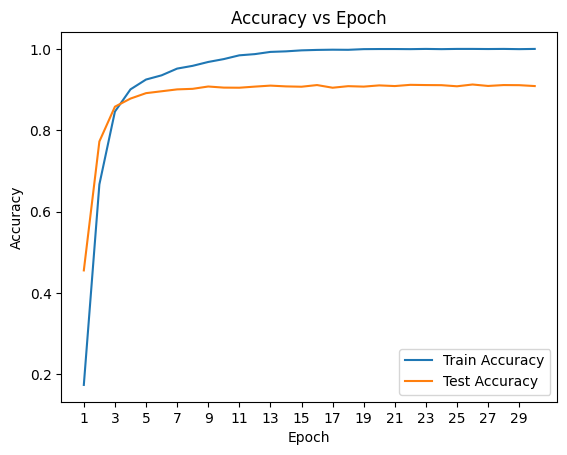

In [ ]:
importlib.reload(bp)
# bp.set_seed(42)
l = 2
num_classes = 37
base_lr = 1e-5
num_epochs = 30

model = bp.get_model_finetune(num_classes=num_classes)
bp.unfreeze_layers(model, l)
model = model.to(device)

optimizer = bp.get_optimizer(model, l, base_lr=base_lr)
criterion = nn.CrossEntropyLoss()

train_losses, test_losses, train_accs, test_accs, best_model, best_acc = bp.train_with_history(
    model, train_loader, test_loader, optimizer, criterion, device, num_epochs=num_epochs
)
model.load_state_dict(best_model)
final_model = model
torch.save(final_model.state_dict(), "resnet34_l2.pth")

print(f"\nBest test acc: {best_acc:.4f}")

bp.plot_training_curves(train_losses, test_losses, train_accs, test_accs)
